In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [8]:
x,_=make_blobs(n_samples=100,centers=1,cluster_std=2,random_state=42)


In [9]:
def divisive_clustering(data,max_clusters=4):   #max_clusters=4
    clusters=[data]  #clusters=[x]
    labels=np.zeros(len(data),dtype=int)  #labels=np.zeroes(100,dtype=int)
    while len(clusters)<max_clusters:  #while len(clusters)<4
        idx_t0_split=np.argmax([len(c)for c in clusters])  #    idx_t0_split=np.argmax([len(c)for c in clusters])
        cluster_to_split=clusters.pop(idx_t0_split)  #cluster_to_split=clusters.pop(idx_t0_split)
        #get a new label to assign to the newly formed cluster
        current_label=max(labels)+1  #current_label=max(labels)+1
        #kmeans used to split the cluster
        kmeans=KMeans(n_clusters=2,random_state=42)
        kmeans.fit(cluster_to_split)
        split_labels=kmeans.fit_predict(cluster_to_split)
        cluster1=cluster_to_split[split_labels==0]
        cluster2=cluster_to_split[split_labels==1]
        clusters.append(cluster1)
        clusters.append(cluster2)
        #update label assignments
        label_indices=np.where([np.any(np.all(x==cluster_to_split, axis=1)) for x in data])[0]

        label_subset=split_labels
        labels[label_indices]=current_label
        labels[label_indices[label_subset==0]]=current_label
        labels[label_indices[label_subset==1]]=current_label+1
    return labels

    
      

In [10]:
cluster_labels=divisive_clustering(x,max_clusters=4)

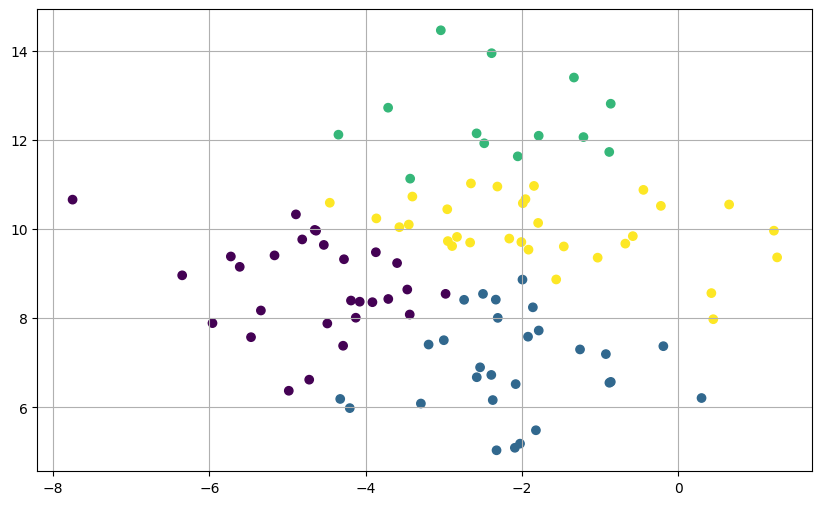

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(x[:,0],x[:,1],c=cluster_labels)
plt.grid()
plt.show()  